In [1]:
import sys
sys.path.append("../src")
from simulation_core.potential.norms import build_inv_norm_matrix
# from simulation_core.potential.potentiel import build_potential_vector
import numpy as np
from scipy.spatial.transform import Rotation

In [2]:
theta = 108 * 2*np.pi/360
r_oh = 0.5

In [3]:
n = 1000
Lx, Ly, Lz = 20, 20, 20
R = Rotation.random(n)
quats = R.as_quat().reshape(4*n)
v = np.concatenate([
    -Lx/2 + Lx * np.random.rand(n),
    -Ly/2 + Ly * np.random.rand(n),
    -Lz/2 + Lz * np.random.rand(n),
    np.zeros(3 * n),
    quats
])
q_o = 1.0
q_h = 1.0
nbr_list = np.ones((n,n))- np.eye(n)

In [4]:
import quaternion as qtn

In [5]:
M = build_inv_norm_matrix(n, v, Lx, Ly, Lz, nbr_list, theta, r_oh)

In [ ]:
np.array(M[1])

9

In [5]:
U = build_potential_vector(n, v, Lx, Ly, Lz, nbr_list, theta, r_oh, q_o, q_h)

In [6]:
U

array([1076.89822123, 1064.35064496, 1073.21841454, 1087.70381329,
       1072.15838116, 1102.43709504, 1071.5303436 , 1119.22990435,
       1039.27215512, 1030.93962361, 1024.43264086, 1077.461216  ,
       1058.15450653, 1047.26568904, 1073.47997683, 1052.06854203,
       1122.77339172, 1056.00159513, 1077.88831905, 1101.8993622 ,
       1082.80787103, 1128.42811247, 1062.02303111, 1062.92576546,
       1103.4770425 , 1073.08617669, 1126.6074231 , 1046.25407491,
       1092.39647094, 1083.91651171, 1109.97925296, 1073.86468677,
       1067.01997645, 1085.89167087, 1063.08591326, 1109.04116563,
       1056.94211185, 1096.013923  , 1045.39704219, 1041.71574473,
       1060.16537531, 1049.64276669, 1085.45226964, 1049.01438811,
       1104.89413781, 1058.21849435, 1065.17525589, 1052.30347709,
       1043.69254519, 1088.09324821, 1074.65365447, 1038.301497  ,
       1078.73777655, 1075.17664905, 1070.43731559, 1067.59324139,
       1100.48669071, 1066.62386625, 1099.62000475, 1064.02936

In [28]:
import time
import matplotlib.pyplot as plt

In [ ]:
# list_n = np.array([50, 100, 250, 500, 750, 1000, 1500, 2000])
list_n = np.array(np.arange(200))
list_t = []

q_o = 1.0
q_h = 1.0
Lx, Ly, Lz = 20, 20, 20
theta = 108 * 2*np.pi/360
r_oh = 0.5

for n in list_n:
    R = Rotation.random(n)
    quats = R.as_quat().reshape(4*n)
    v = np.concatenate([
        -Lx/2 + Lx * np.random.rand(n),
        -Ly/2 + Ly * np.random.rand(n),
        -Lz/2 + Lz * np.random.rand(n),
        np.zeros(3 * n),
        quats
    ])
    nbr_list = np.ones((n,n))- np.eye(n)

    start = time.time()
    
    # U = build_potential_vector(n, v, Lx, Ly, Lz, nbr_list, theta, r_oh, q_o, q_h)

    t = time.time() - start
    list_t.append(t)

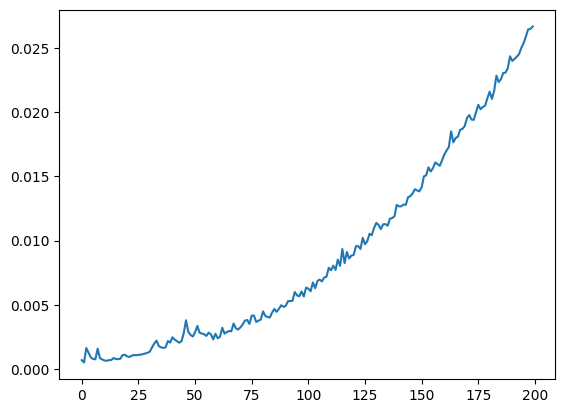

In [34]:
plt.plot(list_n, list_t)
plt.show()